# Introducción al Machine Learning aplicado a Finanzas

En este cuaderno trabajaremos con un **dataset sintético** sobre riesgo crediticio para ilustrar conceptos clave de Machine Learning:

- `DecisionTreeClassifier`
- `random_state`
- `accuracy_score`
- Subajuste y sobreajuste
- `train_test_split`
- Ajuste de hiperparámetros (Grid / Random Search)
- `RandomForestClassifier`
- `LogisticRegression`

Cada sección incluye **explicación**, **importancia** y **ejercicios con solución**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
np.random.seed(42)

## 1. Generación del dataset financiero sintético

Simularemos registros de **solicitudes de crédito** donde la variable objetivo es si el cliente incumplirá el pago (`default`).

In [2]:

X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=5,
    n_redundant=1,
    n_clusters_per_class=2,
    class_sep=1.5,
    flip_y=0.03,
    random_state=42,
)
features = [
    "ingresos",               # Ingreso anual estandarizado
    "deuda_ingreso",          # Relación deuda/ingreso
    "puntuacion_crediticia",  # Puntuación crediticia (scaled)
    "cuentas_abiertas",       # Nº de cuentas abiertas
    "historia_credito",       # Años de historial crediticio
    "porcentaje_uso_tarjeta", # % de uso de tarjeta de crédito
]

df = pd.DataFrame(X, columns=features)
df["default"] = y
df.head()

,ingresos,deuda_ingreso,puntuacion_crediticia,cuentas_abiertas,historia_credito,porcentaje_uso_tarjeta,default
0,1.688332,0.255510,3.140596,1.917113,-1.710680,4.149613,0
1,4.309700,0.296336,-1.116339,2.261924,-1.591984,4.685036,0
2,0.655659,1.312051,1.594877,1.498932,-1.480275,3.260482,0
3,-4.715147,1.369520,-1.456123,0.164776,-3.343925,-2.396500,1
4,-1.982620,0.224440,-2.006466,2.541897,-1.480853,-3.049775,1


## 2. División de datos: `train_test_split`

Separar el conjunto de datos en entrenamiento y prueba permite evaluar el rendimiento en datos **no vistos**.

In [30]:

X = df[features]
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=23, stratify=y
)
print(f"Tamaño entrenamiento: {X_train.shape}, prueba: {X_test.shape}")

Tamaño entrenamiento: (700, 6), prueba: (300, 6)


In [28]:
X_test

,ingresos,deuda_ingreso,puntuacion_crediticia,cuentas_abiertas,historia_credito,porcentaje_uso_tarjeta
622,0.846064,1.014971,5.105669,2.042684,-0.032212,3.762358
860,0.204216,-1.894331,-1.139683,-0.058119,-1.797987,-0.966405
873,-1.247039,0.881454,1.972392,0.500774,-1.669381,1.454304
986,-0.381411,2.267424,3.098907,1.701166,0.839419,2.135205
772,5.135314,-0.522286,-0.360447,-2.583408,3.544167,3.629050
...,...,...,...,...,...,...
668,-0.437517,0.190066,1.533220,-1.572456,-0.267159,1.330728
575,-0.601368,2.017452,-2.578045,2.886091,-0.770534,-0.665587
846,1.121054,0.660636,3.143524,2.264068,-1.672582,3.750192
70,1.452686,-0.692699,-1.060724,0.377043,-2.097019,1.682943


## 3. Árbol de Decisión: `DecisionTreeClassifier`

Los árboles de decisión son modelos interpretables que dividen el espacio de características mediante reglas binarias.

In [38]:

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Accuracy Árbol de Decisión:", accuracy_score(y_test, y_pred_dt))

Accuracy Árbol de Decisión: 0.8866666666666667


**Ejercicio 3.1 — Variar `max_depth`**

Ajusta el parámetro `max_depth` a `1`, `3` y `10` y observa cómo cambia el desempeño en entrenamiento y prueba. ¿Qué conclusiones obtienes sobre **subajuste** y **sobreajuste**?

In [6]:
# Solución ejercicio 3.1
depths = [1, 3, 10]
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"max_depth={d:>2}: train={train_acc:.3f}, test={test_acc:.3f}")

max_depth= 1: train=0.762, test=0.685
max_depth= 3: train=0.948, test=0.905
max_depth=10: train=0.998, test=0.905


## 4. Semilla de aleatoriedad: `random_state`

Usar `random_state` garantiza **reproducibilidad**.

In [7]:

model_a = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
model_b = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
print("¿Los modelos son iguales?", np.array_equal(model_a.predict(X_test), model_b.predict(X_test)))

¿Los modelos son iguales? True


**Ejercicio 4.1**

Entrena dos árboles con `random_state` distintos (p. ej. 0 y 7) y compara la profundidad y el accuracy.

In [8]:
# Solución ejercicio 4.1
for rs in [0, 7]:
    m = DecisionTreeClassifier(random_state=rs).fit(X_train, y_train)
    print(f"rs={rs}: profundidad={m.get_depth()}, accuracy={accuracy_score(y_test, m.predict(X_test)):.3f}")

rs=0: profundidad=12, accuracy=0.910
rs=7: profundidad=12, accuracy=0.925


## 5. Métrica `accuracy_score`

`accuracy_score` mide la proporción de predicciones correctas. Es adecuada para clases balanceadas.

In [9]:

print("Accuracy en prueba (Árbol):", accuracy_score(y_test, y_pred_dt))

Accuracy en prueba (Árbol): 0.905


**Ejercicio 5.1**

Calcula y compara el accuracy de un **clasificador aleatorio** (utiliza `np.random.randint`).

In [11]:
# Solución ejercicio 5.1
rand_pred = np.random.randint(0, 2, size=y_test.shape)
print("Accuracy aleatorio:", accuracy_score(y_test, rand_pred))

Accuracy aleatorio: 0.525


## 6. Subajuste y Sobreajuste

Entrenaremos árboles con diferentes profundidades y graficaremos accuracy en entrenamiento y prueba.

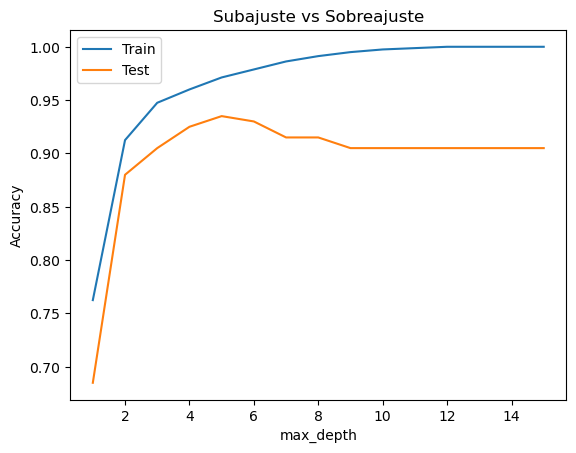

In [12]:

max_depths = range(1, 16)
train_scores, test_scores = [], []
for d in max_depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))
plt.plot(max_depths, train_scores, label="Train")
plt.plot(max_depths, test_scores, label="Test")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Subajuste vs Sobreajuste")
plt.legend()
plt.show()

## 7. Ajuste de Hiperparámetros con `GridSearchCV`

Buscaremos la mejor combinación de `max_depth` y `min_samples_leaf` para el Árbol.

In [15]:

param_grid = {
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 5, 10],
}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
gs.fit(X_train, y_train)
print("Mejores parámetros:", gs.best_params_)
print("Accuracy validación cruzada:", gs.best_score_)
print("Accuracy prueba:", accuracy_score(y_test, gs.predict(X_test)))

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 1}
Accuracy validación cruzada: 0.9425000000000001
Accuracy prueba: 0.935


**Ejercicio 7.1**

Añade `criterion=['gini','entropy']` al `param_grid` y analiza el impacto en el desempeño.

In [16]:
# Solución ejercicio 7.1
param_grid2 = {
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"],
}
gs2 = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid2, cv=5, n_jobs=-1)
gs2.fit(X_train, y_train)
print(gs2.best_params_)
print("Best CV:", gs2.best_score_.round(3), " | Test:", accuracy_score(y_test, gs2.predict(X_test)))

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1}
Best CV: 0.943  | Test: 0.935


## 8. Bosques Aleatorios: `RandomForestClassifier`

Combina múltiples árboles para reducir varianza y mejorar generalización.

In [17]:

rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf.fit(X_train, y_train)
print("Accuracy Bosque Aleatorio:", accuracy_score(y_test, rf.predict(X_test)))

Accuracy Bosque Aleatorio: 0.96


**Ejercicio 8.1**

Entrena un bosque con `n_estimators` de 10, 50 y 500. Grafica el accuracy y el tiempo de entrenamiento.

In [18]:
# Solución ejercicio 8.1
import time
sizes = [10, 50, 500]
for n in sizes:
    start = time.time()
    m = RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train, y_train)
    elapsed = time.time() - start
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"n_estimators={n:<3} | acc={acc:.3f} | tiempo={elapsed:.2f}s")

n_estimators=10  | acc=0.950 | tiempo=0.04s
n_estimators=50  | acc=0.955 | tiempo=0.12s
n_estimators=500 | acc=0.955 | tiempo=1.07s


## 9. Regresión Logística: `LogisticRegression`

Modelo lineal para clasificación binaria que estima la probabilidad de pertenencia a una clase.

In [19]:

log_reg = LogisticRegression(max_iter=1000, solver="lbfgs")
log_reg.fit(X_train, y_train)
print("Accuracy Regresión Logística:", accuracy_score(y_test, log_reg.predict(X_test)))

Accuracy Regresión Logística: 0.865


**Ejercicio 9.1**

Ajusta el parámetro `C` a `[0.01, 0.1, 1, 10]` y observa el impacto en el accuracy y la magnitud de los coeficientes.

In [20]:
# Solución ejercicio 9.1
for c in [0.01, 0.1, 1, 10]:
    clf = LogisticRegression(C=c, max_iter=1000, solver="lbfgs").fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    coef_mag = np.linalg.norm(clf.coef_)
    print(f"C={c:<4} | acc={acc:.3f} | ||coef||={coef_mag:.2f}")

C=0.01 | acc=0.875 | ||coef||=0.98
C=0.1  | acc=0.865 | ||coef||=1.62
C=1    | acc=0.865 | ||coef||=1.84
C=10   | acc=0.865 | ||coef||=1.87


## Conclusiones

- **Árboles** son interpretables pero pueden sobreajustar.
- **Semillas (`random_state`)** proporcionan reproducibilidad.
- Elegir la **métrica** adecuada es crucial; `accuracy` es sensible a desbalance.
- **Validación cruzada** y **búsqueda de hiperparámetros** mejoran el rendimiento.
- **Ensamblajes** como Random Forest usualmente superan modelos sencillos.
- **Regresión Logística** es un buen punto de partida para problemas lineales.